##### Figure S2: Predicted X/A diversity ratio after a population size reduction.

##### Implementation based on:
##### John E. Pool, Rasmus Nielsen 
##### Population Size Changes Reshape Genomic Patterns of Diversity
##### Evolution, 2007
##### https://doi.org/10.1111/j.1558-5646.2007.00238.x
##### Equation (4):

##### Parameters:
#####     h1 = 0.75  (X-linked inheritance factor)
#####     h2 = 1.0   (autosomal inheritance factor)
#####     mu1 = mu2  (equal mutation rates => ratio cancels out)
#####     N  = 12_000 (GSL) / 17_000 (SSL) (initial population size)
#####     f  = N_new / N_old  (size change factor; 1/f = fold reduction magnitude)
#####     g  = generations since the size change

In [320]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

In [321]:
def xa_ratio_reduction(g, f, N, h1=0.75, h2=1.0, alpha=3):

    # numerator, X
    numer = f - (f - 1) * (1 - 1 / (2 * N * h1 * f)) ** g
    # denominator, AUT
    denom = f - (f - 1) * (1 - 1 / (2 * N * h2 * f)) ** g
    mu = (4 + 2 * alpha) / (3 + 3 * alpha)

    return (h1 / h2) * mu * (numer / denom)

In [322]:
def plot_population(N, alpha, g_max, figsize=(6, 5), palette="plasma", hline=10, ylim=100, ax=None, show_cbar=False):
    g_values = np.linspace(0, g_max, 400)

    inv_f_values = np.linspace(1, ylim, ylim*100) # 1=1/1 (no change); 500=1/500 (severe reduction)
    f_values     = 1.0 / inv_f_values

    # rows = 1/f, cols = g
    G, F = np.meshgrid(g_values, f_values)
    Z = xa_ratio_reduction(G, F, N, alpha=alpha)

    bounds = [0.0, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80]
    colors = sns.color_palette(palette, len(bounds)).as_hex()

    cmap = mcolors.ListedColormap(colors)
    norm = mcolors.BoundaryNorm(bounds, cmap.N)

    # fig, ax = plt.subplots(figsize=figsize)

    pcm = ax.pcolormesh(
        g_values, # g
        inv_f_values, # 1/f
        Z,
        cmap=cmap,
        norm=norm,
        shading="auto",
    )
    if show_cbar:
        cbar = fig.colorbar(pcm, ax=ax, ticks=bounds, label="X/A diversity ratio")
        cbar.ax.set_yticklabels(
            ["0", "0.30", "0.40", "0.50", "0.60", "0.70", "0.80"]
        )

    ax.axhline(y=hline, color='black', linestyle='--', linewidth=0.8)
    ax.text(g_max-18_000, hline+1, f"population size reduction=1/{hline}", rotation=0, style="italic")

    ax.set_xlabel("g (generations since size reduction)", fontsize=11)
    ax.set_ylabel("1/f  (fold reduction)", fontsize=11)
    ax.set_xlim(0, g_max)
    ax.set_ylim(1, ylim)
    ax.set_title(rf"$N={N},\alpha={alpha}$", fontsize=12)

    # plt.tight_layout()
    # plt.show()
    return ax, pcm

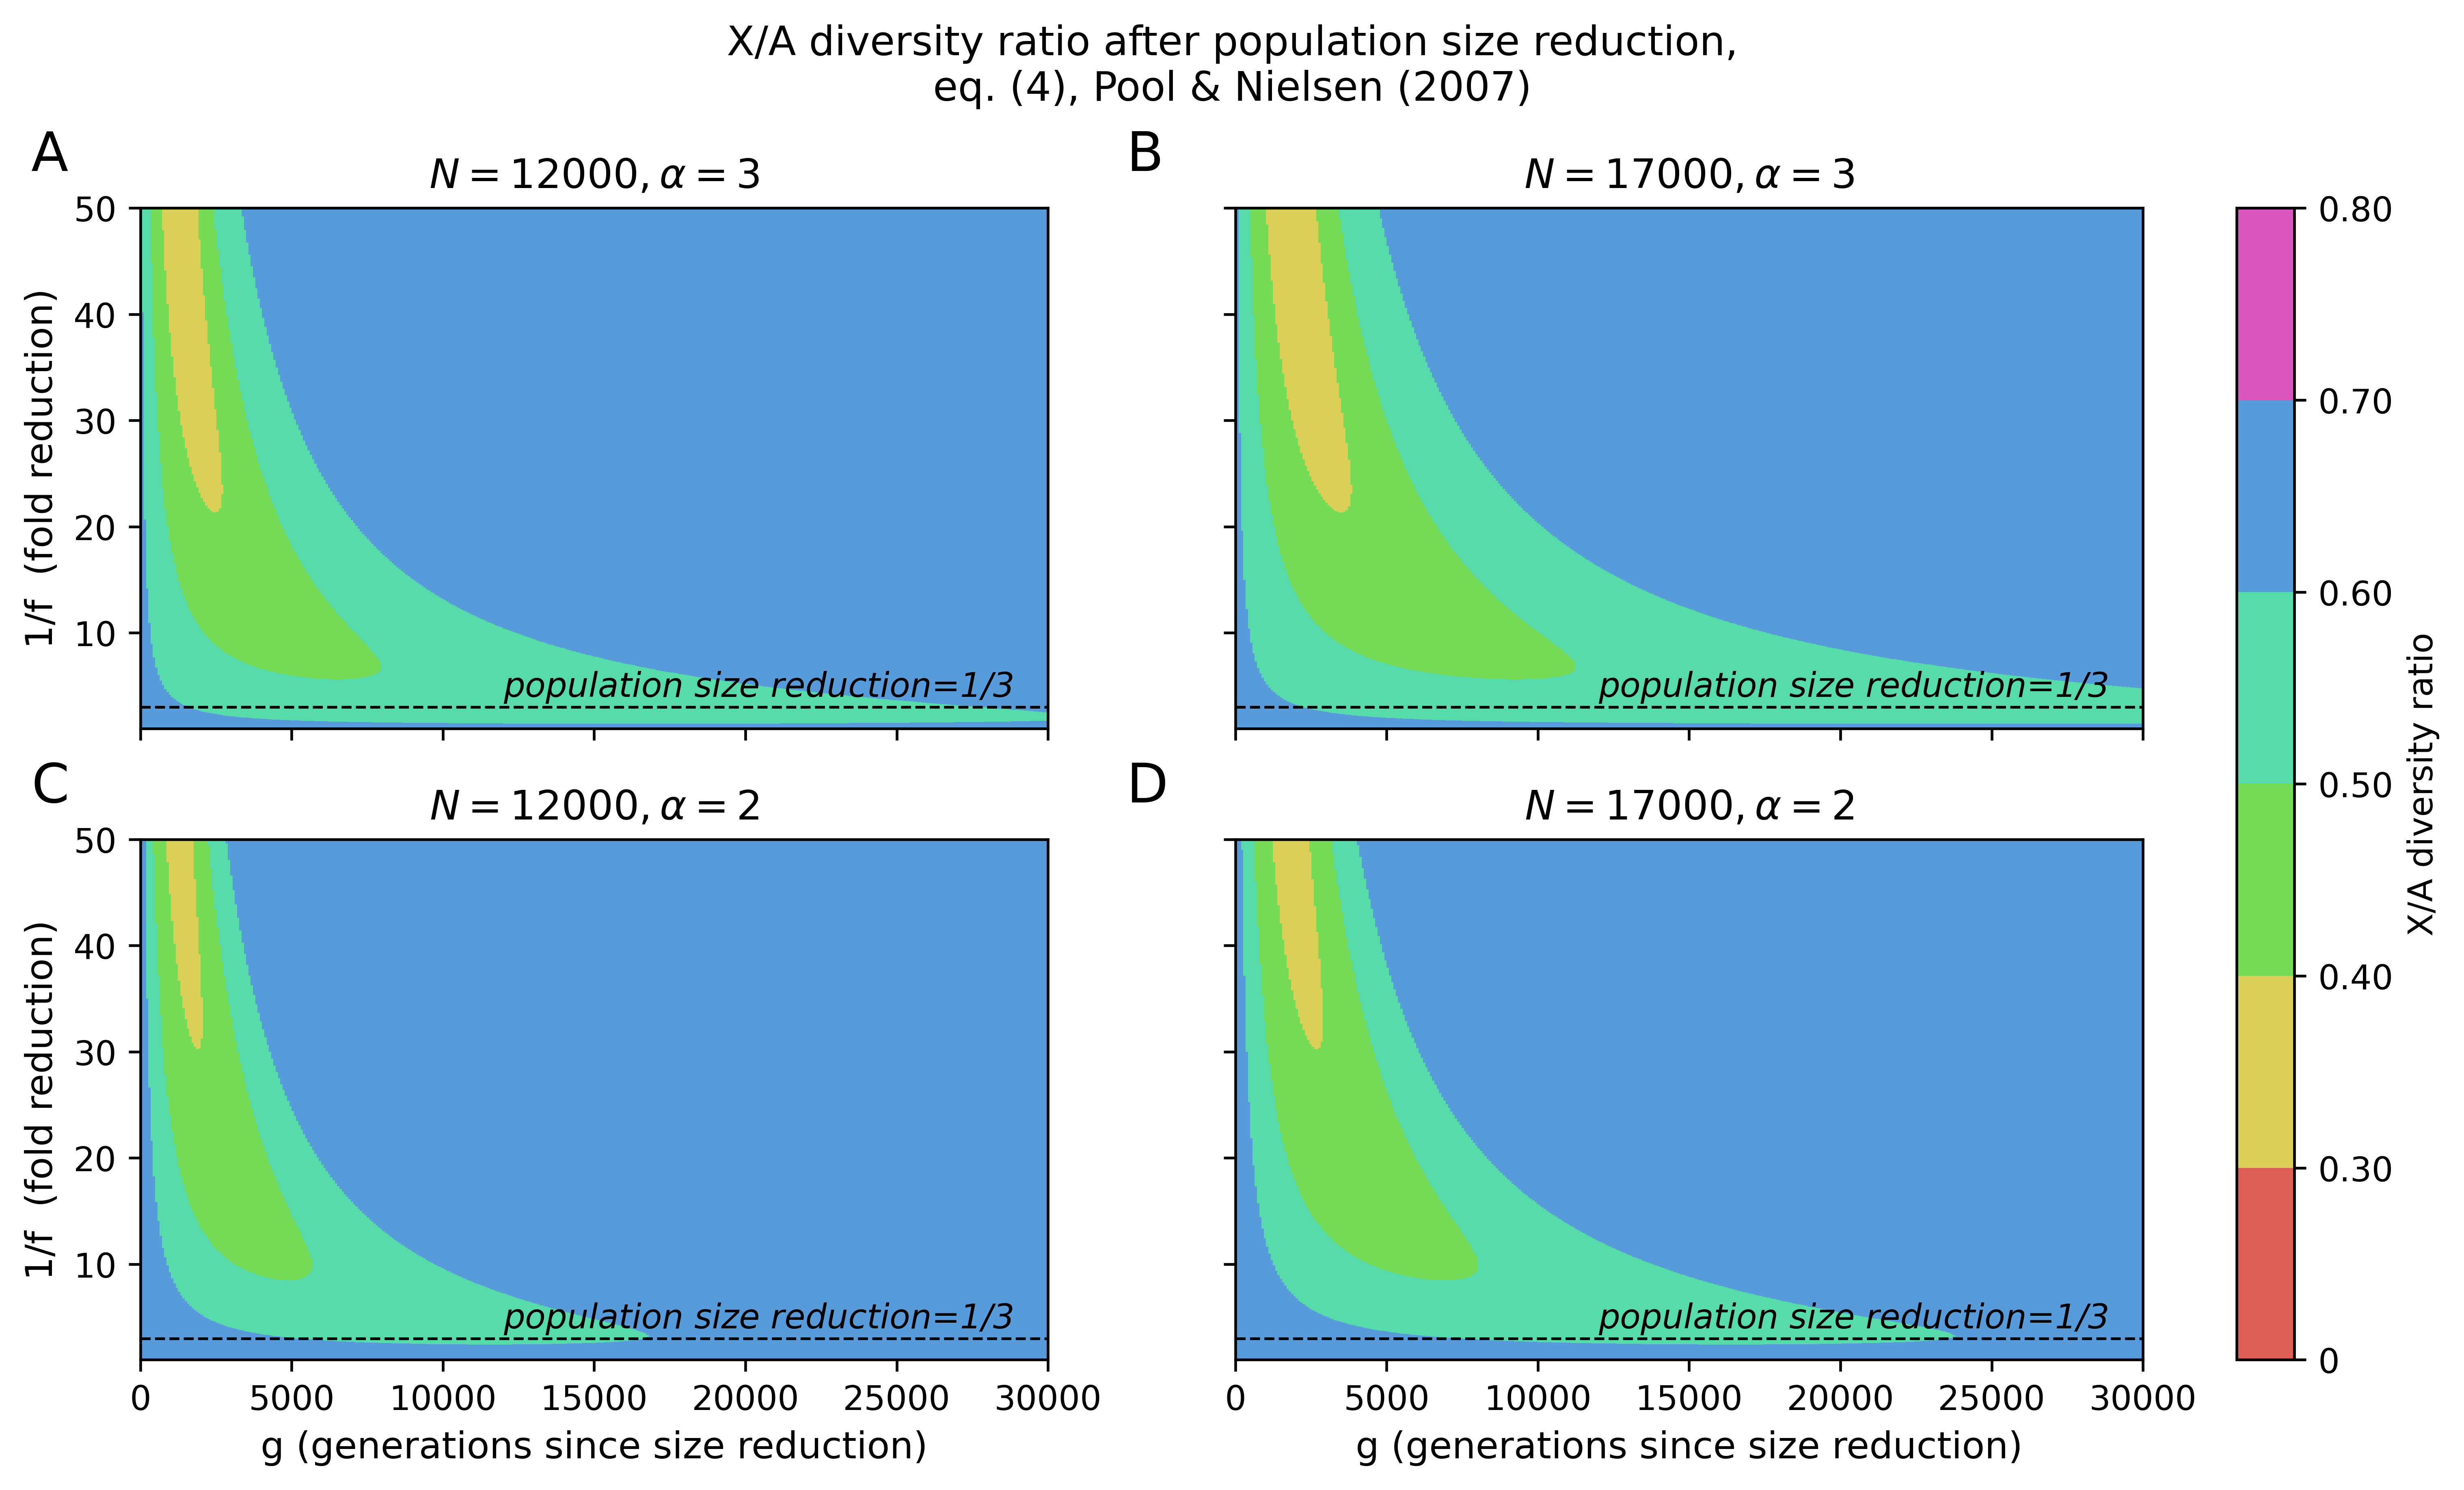

In [324]:
fig, axes = plt.subplots(
    2, 2, figsize=(10, 6),
    sharex=True, sharey=True,
    layout="constrained", dpi=600
)

parameters = [
    (12_000, 3, "A"),
    (17_000, 3, "B"),
    (12_000, 2, "C"),
    (17_000, 2, "D"),
]

for ax, (N, alpha, lbl) in zip(axes.flat, parameters):
    _, pcm = plot_population(
        N=N,
        alpha=alpha,
        g_max=30_000,
        hline=3,
        ylim=50,
        ax=ax,
        palette="hls"
    )
    ax.label_outer()
    ax.text(
        -0.12, 1.05, lbl,
        transform=ax.transAxes,
        fontsize=16,
        ha="left",
        va="bottom",
        clip_on=False,
    )

bounds = [0.0, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80]
cbar = fig.colorbar(
    pcm,
    ax=axes.ravel().tolist(),
    ticks=bounds,
    label="X/A diversity ratio",
    pad=0.02
)
cbar.ax.set_yticklabels(
    ["0", "0.30", "0.40", "0.50", "0.60", "0.70", "0.80"]
)
fig.suptitle("X/A diversity ratio after population size reduction,\neq. (4), Pool & Nielsen (2007)", fontsize=12)

plt.show()